# Task 1: Visually Exploring a Dataset
### Dataset: student_habits_performance.csv

## Setup

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
from scipy.stats import pearsonr
warnings.filterwarnings('ignore')

# Set default plot style (background grid) and fallback color palette for any plot without an explicit color specified
sns.set_theme(style="whitegrid", palette="pastel")

# Load dataset
df = pd.read_csv('student_habits_performance.csv')

# Overview
print(df.shape)
df.info()

(1000, 16)
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     1000 non-null   str    
 1   age                            1000 non-null   int64  
 2   gender                         1000 non-null   str    
 3   study_hours_per_day            1000 non-null   float64
 4   social_media_hours             1000 non-null   float64
 5   netflix_hours                  1000 non-null   float64
 6   part_time_job                  1000 non-null   str    
 7   attendance_percentage          1000 non-null   float64
 8   sleep_hours                    1000 non-null   float64
 9   diet_quality                   1000 non-null   str    
 10  exercise_frequency             1000 non-null   int64  
 11  parental_education_level       909 non-null    str    
 12  internet_quality               1000 non-null   st

In [40]:
df.head()

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


## Data Processing / Cleaning

In [41]:
# Check column names
print(df.columns.tolist())

['student_id', 'age', 'gender', 'study_hours_per_day', 'social_media_hours', 'netflix_hours', 'part_time_job', 'attendance_percentage', 'sleep_hours', 'diet_quality', 'exercise_frequency', 'parental_education_level', 'internet_quality', 'mental_health_rating', 'extracurricular_participation', 'exam_score']


In [42]:
# Check missing values
print(df.isnull().sum())

student_id                        0
age                               0
gender                            0
study_hours_per_day               0
social_media_hours                0
netflix_hours                     0
part_time_job                     0
attendance_percentage             0
sleep_hours                       0
diet_quality                      0
exercise_frequency                0
parental_education_level         91
internet_quality                  0
mental_health_rating              0
extracurricular_participation     0
exam_score                        0
dtype: int64


In [43]:
# Check duplicate rows and ID uniqueness
print("Duplicate rows:", df.duplicated().sum())
print("Unique student_id count:", df['student_id'].nunique(), "out of", len(df))

Duplicate rows: 0
Unique student_id count: 1000 out of 1000


In [44]:
# Check semantic consistency: combined daily hours and bounded columns
daily_hours = (df['study_hours_per_day'] + df['social_media_hours']
               + df['netflix_hours'] + df['sleep_hours'])
print("Max combined daily hours:", daily_hours.max())
print("Rows exceeding 24h:", (daily_hours > 24).sum())

print("attendance_percentage out of [0,100]:",
      ((df['attendance_percentage'] < 0) | (df['attendance_percentage'] > 100)).sum())
print("exam_score out of [0,100]:",
      ((df['exam_score'] < 0) | (df['exam_score'] > 100)).sum())
print("mental_health_rating range:", df['mental_health_rating'].min(), "-", df['mental_health_rating'].max())

Max combined daily hours: 21.5
Rows exceeding 24h: 0
attendance_percentage out of [0,100]: 0
exam_score out of [0,100]: 0
mental_health_rating range: 1 - 10


In [45]:
# Check outliers using IQR method across numeric columns
numeric_cols = ['age','study_hours_per_day','social_media_hours','netflix_hours',
                 'attendance_percentage','sleep_hours','exercise_frequency',
                 'mental_health_rating','exam_score']

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: {len(outliers)} outliers")

age: 0 outliers
study_hours_per_day: 7 outliers
social_media_hours: 5 outliers
netflix_hours: 4 outliers
attendance_percentage: 3 outliers
sleep_hours: 2 outliers
exercise_frequency: 0 outliers
mental_health_rating: 0 outliers
exam_score: 2 outliers


In [46]:
# Handle missing values in parental_education_level
# Treated as its own category rather than dropped or imputed with mode,
# since dropping would lose ~9% of the sample and mode imputation
# would misrepresent the true distribution of this variable
df['parental_education_level'] = df['parental_education_level'].fillna('Unknown')

In [47]:
# Confirm clean, create working copy
print(df.isnull().sum())
df_clean = df.copy()

student_id                       0
age                              0
gender                           0
study_hours_per_day              0
social_media_hours               0
netflix_hours                    0
part_time_job                    0
attendance_percentage            0
sleep_hours                      0
diet_quality                     0
exercise_frequency               0
parental_education_level         0
internet_quality                 0
mental_health_rating             0
extracurricular_participation    0
exam_score                       0
dtype: int64


In [48]:
# Check unique categories in each categorical variable
categorical_cols = ['gender','part_time_job','diet_quality',
                     'parental_education_level','internet_quality',
                     'extracurricular_participation']

for col in categorical_cols:
    print(f"{col}: {df_clean[col].unique()}")

gender: <StringArray>
['Female', 'Male', 'Other']
Length: 3, dtype: str
part_time_job: <StringArray>
['No', 'Yes']
Length: 2, dtype: str
diet_quality: <StringArray>
['Fair', 'Good', 'Poor']
Length: 3, dtype: str
parental_education_level: <StringArray>
['Master', 'High School', 'Bachelor', 'Unknown']
Length: 4, dtype: str
internet_quality: <StringArray>
['Average', 'Poor', 'Good']
Length: 3, dtype: str
extracurricular_participation: <StringArray>
['Yes', 'No']
Length: 2, dtype: str


## Talking Point 1: Who Are the Students? (Demographic Overview)

In [49]:
# Check summary statistics for all numeric variables
df_clean.describe().round(2)

,age,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,exercise_frequency,mental_health_rating,exam_score
count,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00
mean,20.50,3.55,2.51,1.82,84.13,6.47,3.04,5.44,69.60
std,2.31,1.47,1.17,1.08,9.40,1.23,2.03,2.85,16.89
min,17.00,0.00,0.00,0.00,56.00,3.20,0.00,1.00,18.40
25%,18.75,2.60,1.70,1.00,78.00,5.60,1.00,3.00,58.48
50%,20.00,3.50,2.50,1.80,84.40,6.50,3.00,5.00,70.50
75%,23.00,4.50,3.30,2.52,91.02,7.30,5.00,8.00,81.32
max,24.00,8.30,7.20,5.40,100.00,10.00,6.00,10.00,100.00


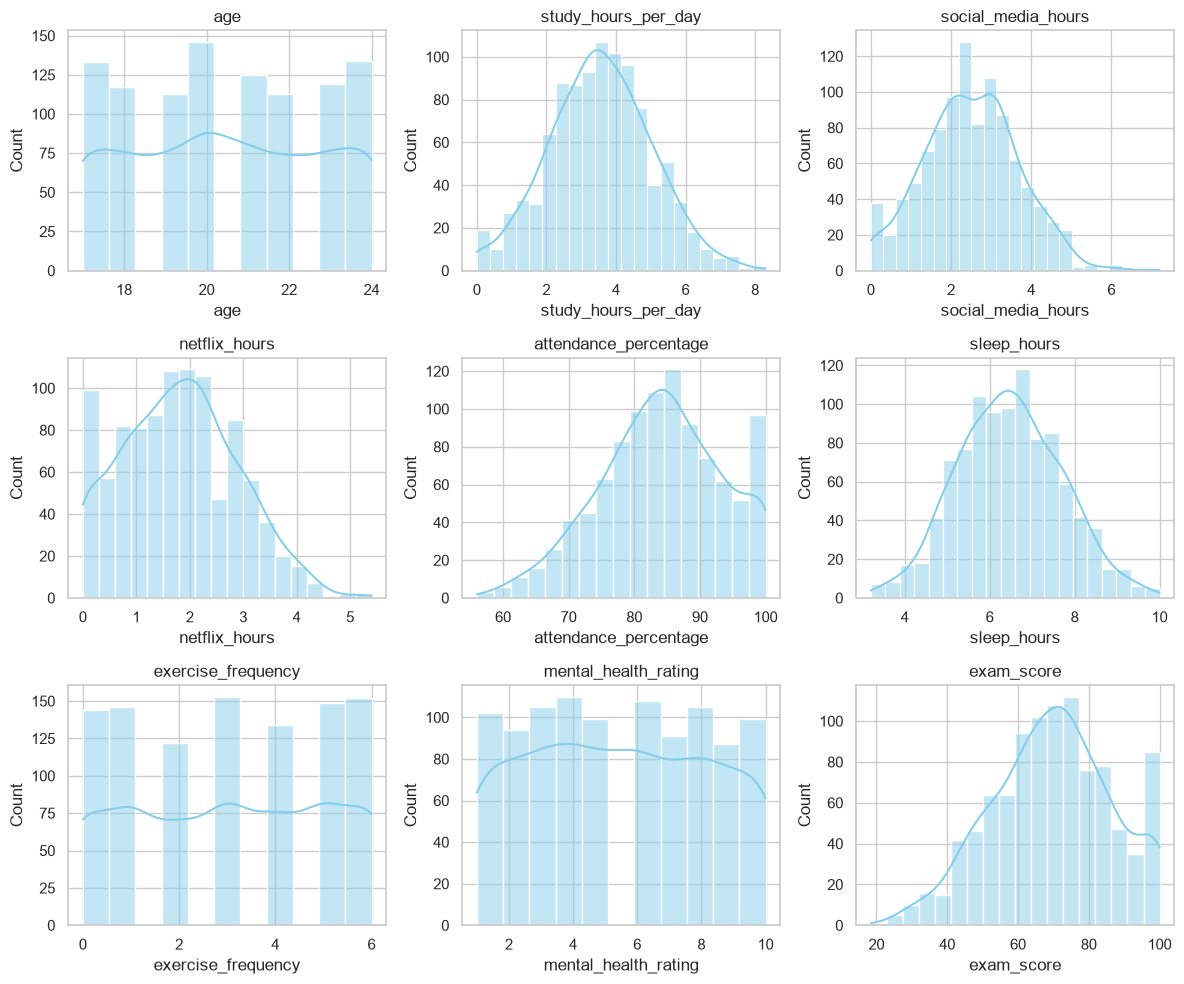

In [50]:
# Check univariate distributions of all numeric variables
numeric_cols = ['age','study_hours_per_day','social_media_hours','netflix_hours',
                 'attendance_percentage','sleep_hours','exercise_frequency',
                 'mental_health_rating','exam_score']

fig, axes = plt.subplots(3, 3, figsize=(12,10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(df_clean[col], kde=True, color='skyblue', ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

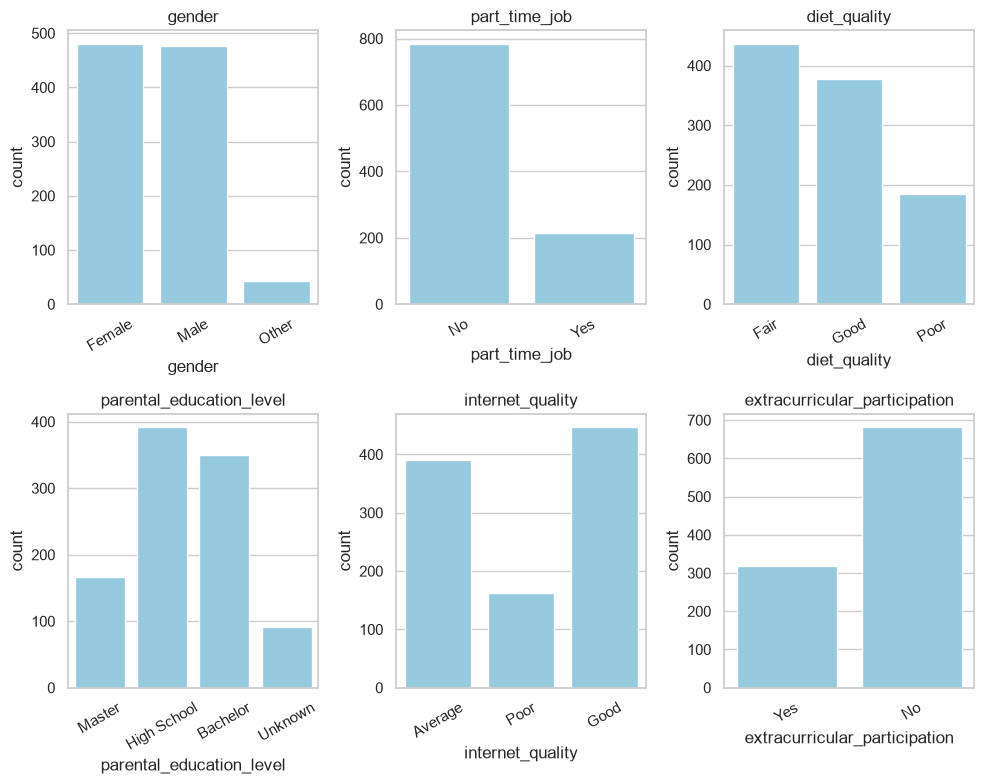

In [51]:
# Check univariate distributions of all categorical variables
categorical_cols = ['gender','part_time_job','diet_quality',
                     'parental_education_level','internet_quality',
                     'extracurricular_participation']

fig, axes = plt.subplots(2, 3, figsize=(10,8))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    sns.countplot(data=df_clean, x=col, color='skyblue', ax=axes[i])
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

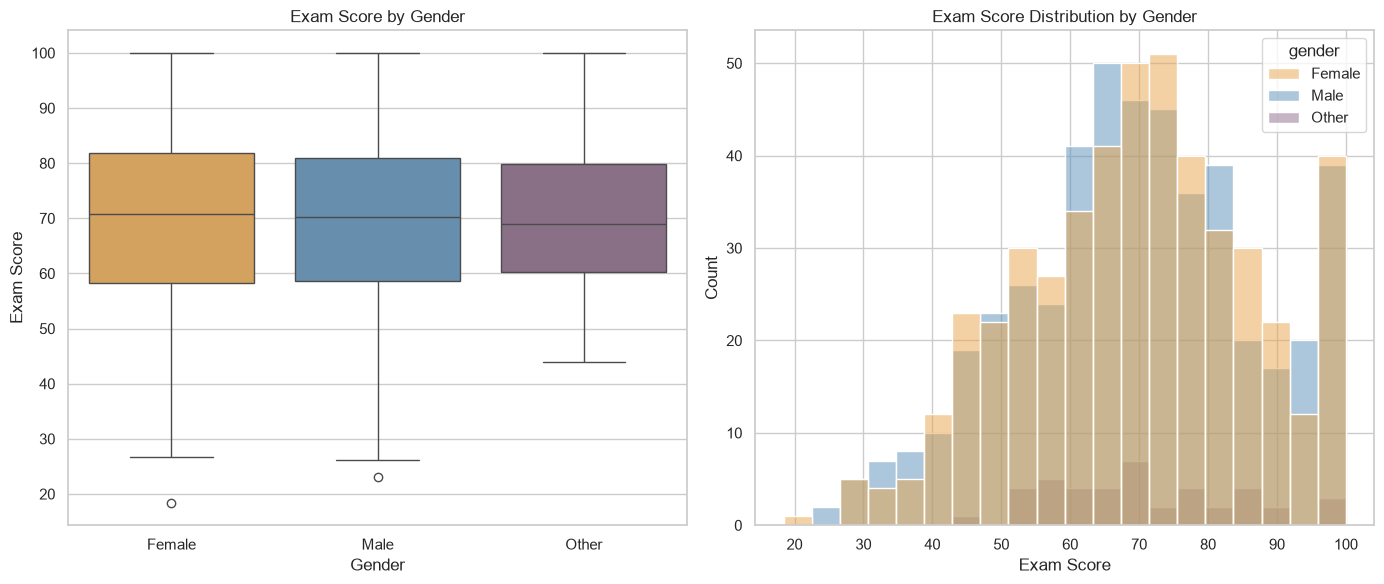

In [52]:
# Check exam score's relationship with gender, side by side
gender_colors = {'Male': '#5B8FB9', 'Female': '#E8A54B', 'Other': '#8E6C8A'}  # neutral, non-stereotyped colors

fig, axes = plt.subplots(1, 2, figsize=(14,6))

# Panel 1: exam score spread by gender
sns.boxplot(data=df_clean, x='gender', y='exam_score', palette=gender_colors, order=['Female','Male','Other'], ax=axes[0])
axes[0].set_title('Exam Score by Gender')
axes[0].set_xlabel('Gender')
axes[0].set_ylabel('Exam Score')

# Panel 2: exam score histogram by gender, actual bins instead of smoothed curve
sns.histplot(data=df_clean, x='exam_score', hue='gender',
             multiple='layer', bins=20, palette=gender_colors, alpha=0.5, ax=axes[1])
axes[1].set_title('Exam Score Distribution by Gender')
axes[1].set_xlabel('Exam Score')

plt.tight_layout()
plt.show()

## Talking Point 2: Overall Exam Performance

In [53]:
# Check descriptive statistics: location and spread of exam_score
print(df_clean['exam_score'].describe().round(2))
print("Mean:", df_clean['exam_score'].mean().round(2))
print("Median:", df_clean['exam_score'].median().round(2))
print("Mode:", df_clean['exam_score'].mode().values[0])

count    1000.00
mean       69.60
std        16.89
min        18.40
25%        58.48
50%        70.50
75%        81.32
max       100.00
Name: exam_score, dtype: float64
Mean: 69.6
Median: 70.5
Mode: 100.0


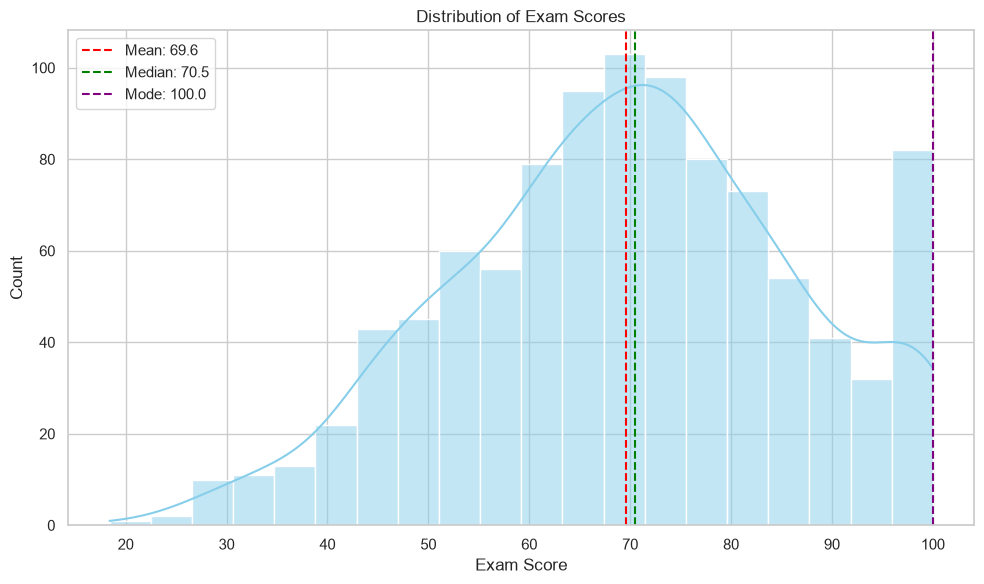

In [54]:
# Check distribution shape of exam_score, with mean, median, and mode marked
plt.figure(figsize=(10,6))
sns.histplot(df_clean['exam_score'], kde=True, bins=20, color='skyblue')

mean_val = df_clean['exam_score'].mean()
median_val = df_clean['exam_score'].median()
mode_val = df_clean['exam_score'].mode()[0]

plt.axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.1f}')
plt.axvline(median_val, color='green', linestyle='--', label=f'Median: {median_val:.1f}')
plt.axvline(mode_val, color='purple', linestyle='--', label=f'Mode: {mode_val:.1f}')

plt.title('Distribution of Exam Scores')
plt.xlabel('Exam Score')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

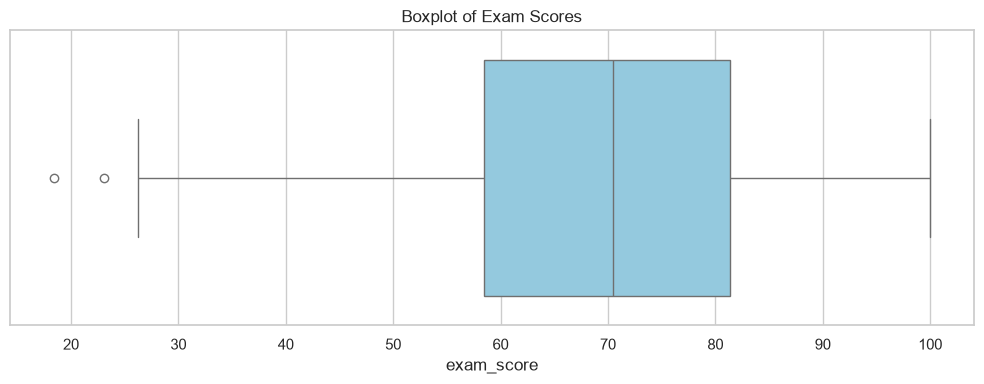

In [55]:
# Check exam_score spread and outliers
plt.figure(figsize=(10,4))
sns.boxplot(x=df_clean['exam_score'], color='skyblue')
plt.title('Boxplot of Exam Scores')
plt.tight_layout()
plt.show()

## Talking Point 3: Study Hours — the Dominant Predictor

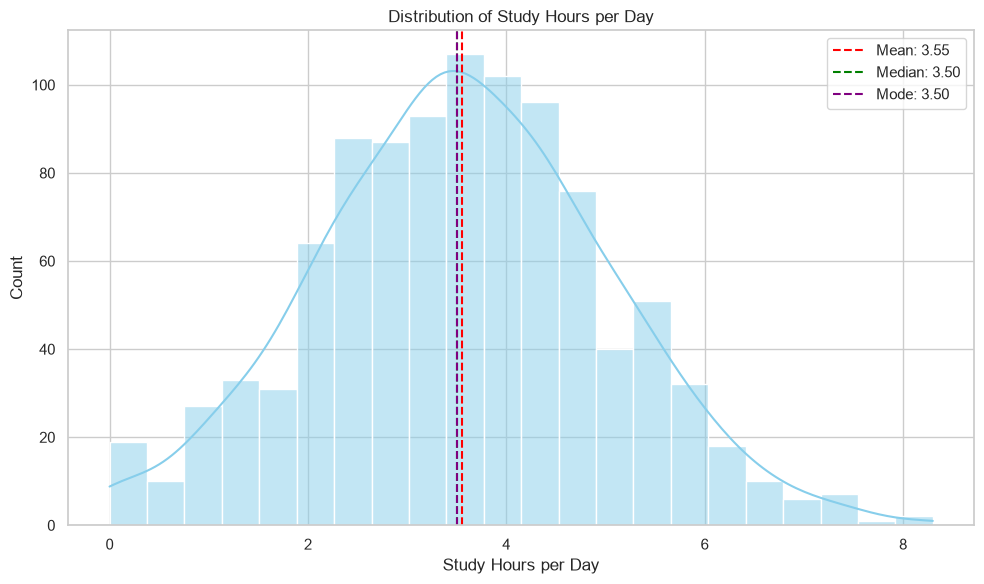

In [56]:
# Check distribution shape of study_hours_per_day, with mean, median, and mode marked
plt.figure(figsize=(10,6))
sns.histplot(df_clean['study_hours_per_day'], kde=True, color='skyblue')

mean_val = df_clean['study_hours_per_day'].mean()
median_val = df_clean['study_hours_per_day'].median()
mode_val = df_clean['study_hours_per_day'].mode()[0]

plt.axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.2f}')
plt.axvline(median_val, color='green', linestyle='--', label=f'Median: {median_val:.2f}')
plt.axvline(mode_val, color='purple', linestyle='--', label=f'Mode: {mode_val:.2f}')

plt.title('Distribution of Study Hours per Day')
plt.xlabel('Study Hours per Day')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

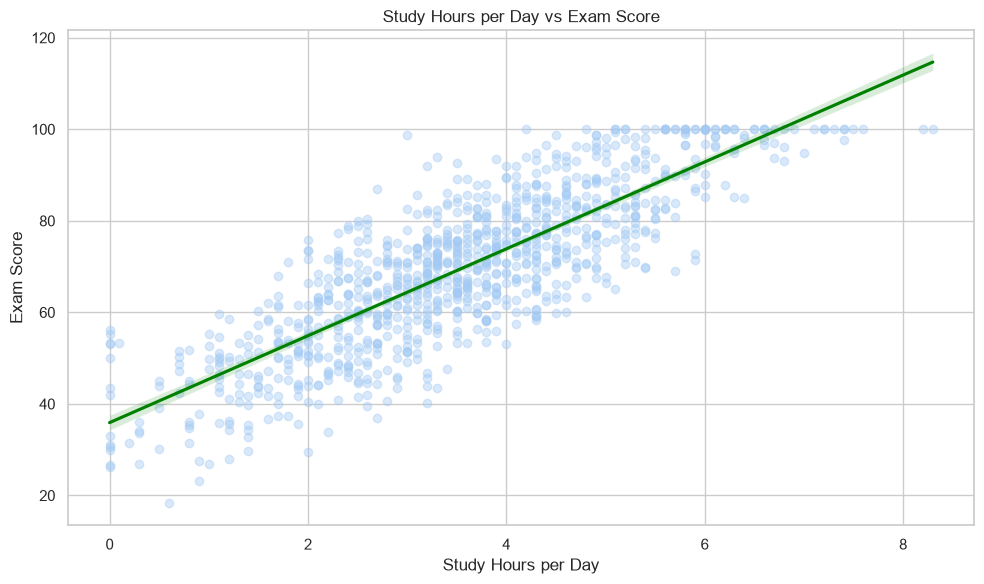

In [57]:
# Check relationship between study hours and exam score
plt.figure(figsize=(10,6))
sns.regplot(data=df_clean, x='study_hours_per_day', y='exam_score',
            scatter_kws={'alpha':0.4}, line_kws={'color':'green'})
plt.title('Study Hours per Day vs Exam Score')
plt.xlabel('Study Hours per Day')
plt.ylabel('Exam Score')
plt.tight_layout()
plt.show()

In [58]:
# Check correlation strength using scipy's pearsonr

corr, p_value = pearsonr(df_clean['study_hours_per_day'], df_clean['exam_score'])
print(f"Correlation: {corr:.2f}")
print(f"P-value: {p_value:.4f}")

Correlation: 0.83
P-value: 0.0000


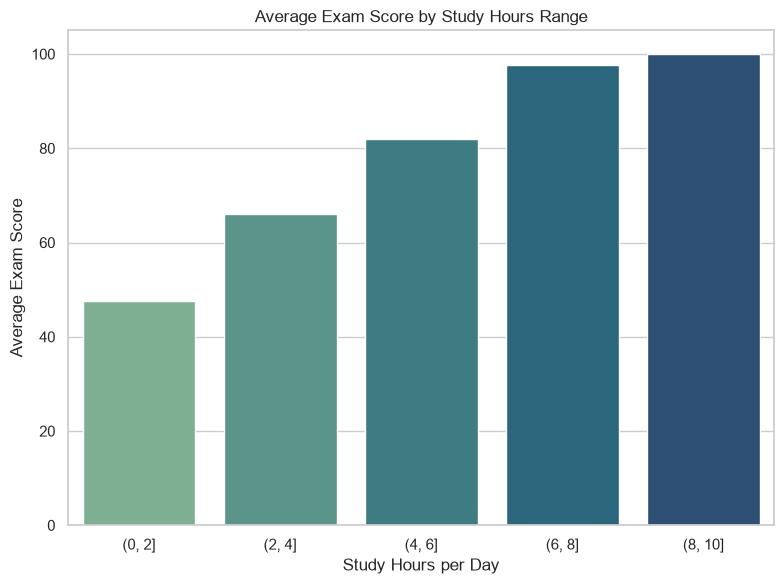

In [59]:
# Check average exam score across study hour ranges
df_clean['study_hours_bin'] = pd.cut(df_clean['study_hours_per_day'], bins=[0,2,4,6,8,10])
binned = df_clean.groupby('study_hours_bin')['exam_score'].mean()

plt.figure(figsize=(8,6))
sns.barplot(x=binned.index.astype(str), y=binned.values, palette='crest')
plt.title('Average Exam Score by Study Hours Range')
plt.xlabel('Study Hours per Day')
plt.ylabel('Average Exam Score')
plt.tight_layout()
plt.show()

## Encoding Categorical Variables for Correlation Analysis

In [60]:
# Encode binary and ordinal categorical variables
df_encoded = df_clean.copy()

# Binary variables: simple 0/1 encoding
df_encoded['part_time_job_encoded'] = df_encoded['part_time_job'].map({'No': 0, 'Yes': 1})
df_encoded['extracurricular_encoded'] = df_encoded['extracurricular_participation'].map({'No': 0, 'Yes': 1})

# Ordinal variables: encode respecting their natural order (not arbitrary alphabetical order)
df_encoded['diet_quality_encoded'] = df_encoded['diet_quality'].map({'Poor': 0, 'Fair': 1, 'Good': 2})
df_encoded['internet_quality_encoded'] = df_encoded['internet_quality'].map({'Poor': 0, 'Average': 1, 'Good': 2})

In [61]:
# One-hot encode nominal variables (no natural order, or order broken by 'Unknown')
df_encoded = pd.get_dummies(df_encoded, columns=['gender', 'parental_education_level'])

## Talking Point 4: Correlation Across All Variables

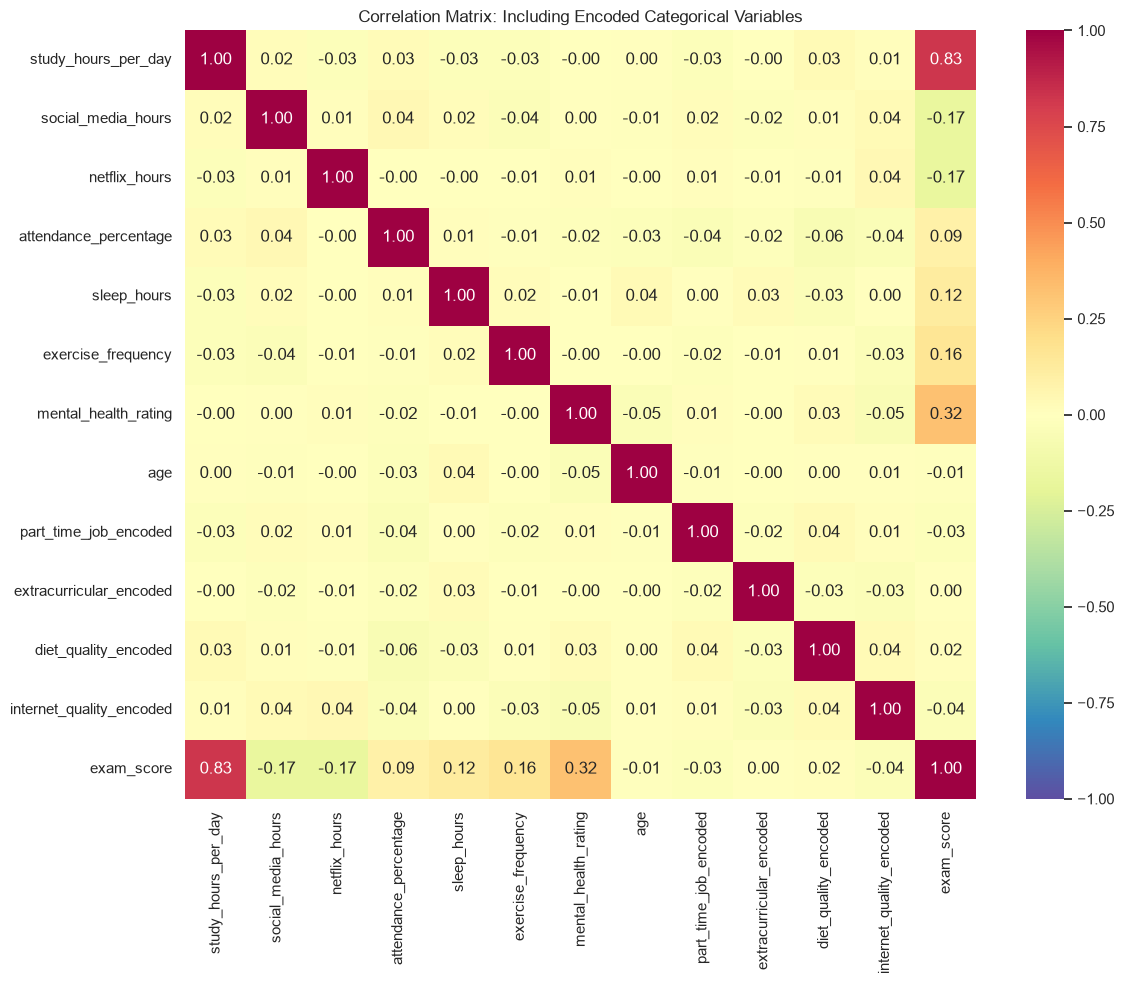

In [62]:
# Check correlation matrix including encoded binary/ordinal categorical variables
extended_cols = ['study_hours_per_day','social_media_hours','netflix_hours',
                  'attendance_percentage','sleep_hours','exercise_frequency',
                  'mental_health_rating','age','part_time_job_encoded',
                  'extracurricular_encoded','diet_quality_encoded',
                  'internet_quality_encoded','exam_score']
corr_matrix_extended = df_encoded[extended_cols].corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix_extended, annot=True, fmt='.2f', cmap='Spectral_r', vmin=-1, vmax=1)
plt.title('Correlation Matrix: Including Encoded Categorical Variables')
plt.tight_layout()
plt.show()

## Talking Point 5: Mental Health and Lifestyle Factors

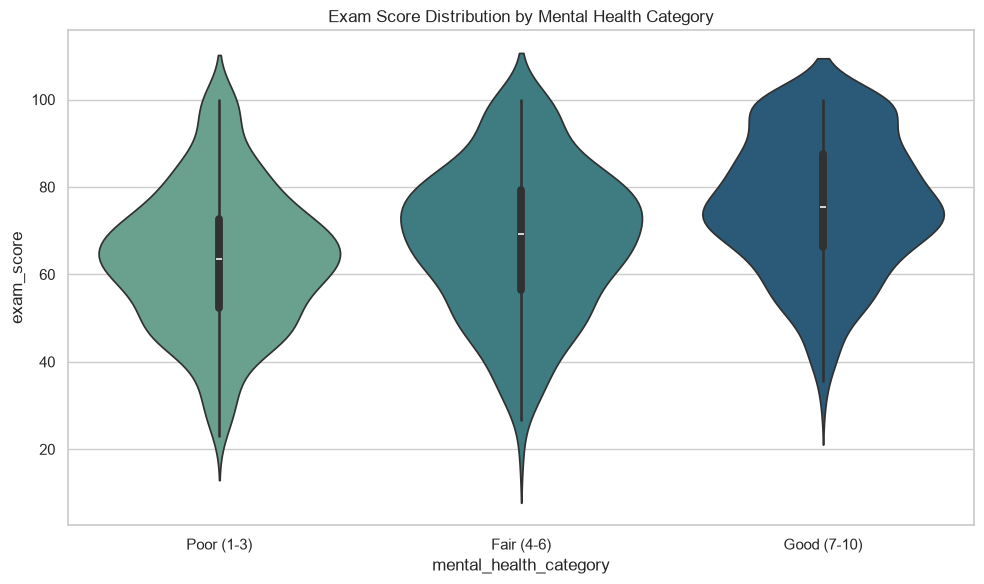

In [63]:
# Group mental health rating into 3 categories using integer boundaries
df_clean['mental_health_category'] = pd.cut(
    df_clean['mental_health_rating'],
    bins=[0, 3, 6, 10],
    labels=['Poor (1-3)', 'Fair (4-6)', 'Good (7-10)']
)

# Check exam score distribution shape across mental health categories
plt.figure(figsize=(10,6))
sns.violinplot(data=df_clean, x='mental_health_category', y='exam_score', palette='crest')
plt.title('Exam Score Distribution by Mental Health Category')
plt.tight_layout()
plt.show()

## Talking Point 6: Digital Distraction Factors

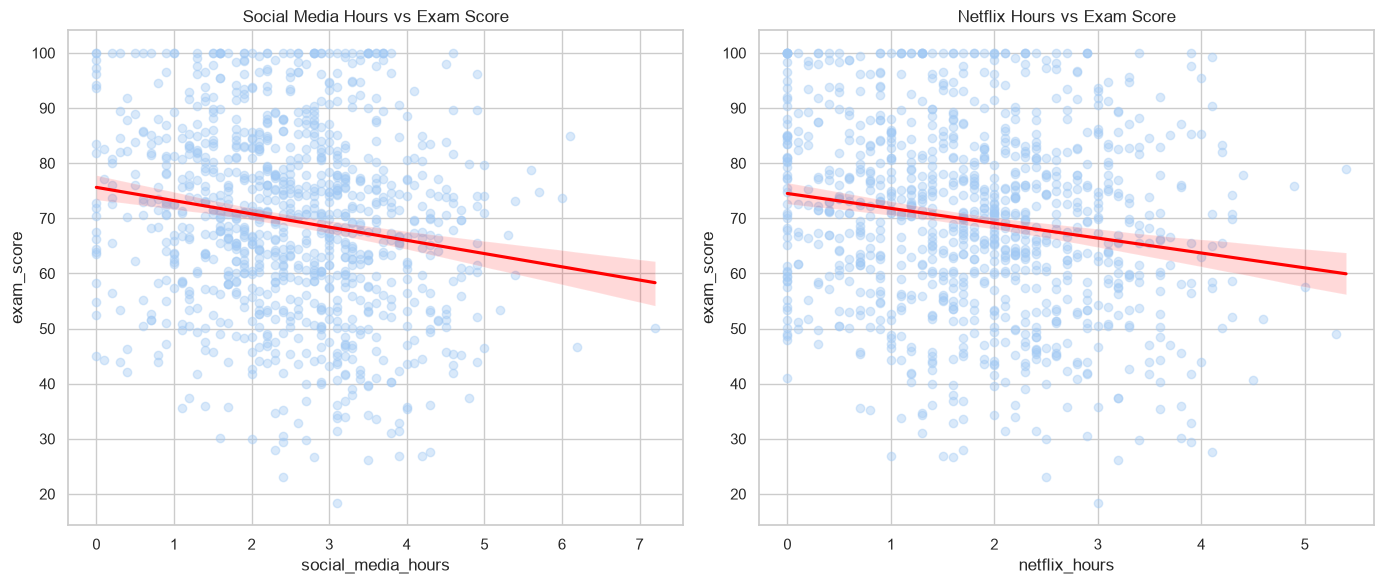

In [64]:
# Check relationship between screen time variables and exam score
fig, axes = plt.subplots(1, 2, figsize=(14,6))
sns.regplot(data=df_clean, x='social_media_hours', y='exam_score',
            scatter_kws={'alpha':0.4}, line_kws={'color':'red'}, ax=axes[0])
axes[0].set_title('Social Media Hours vs Exam Score')

sns.regplot(data=df_clean, x='netflix_hours', y='exam_score',
            scatter_kws={'alpha':0.4}, line_kws={'color':'red'}, ax=axes[1])
axes[1].set_title('Netflix Hours vs Exam Score')
plt.tight_layout()
plt.show()

## Talking Point 7: Healthy Lifestyle Factors

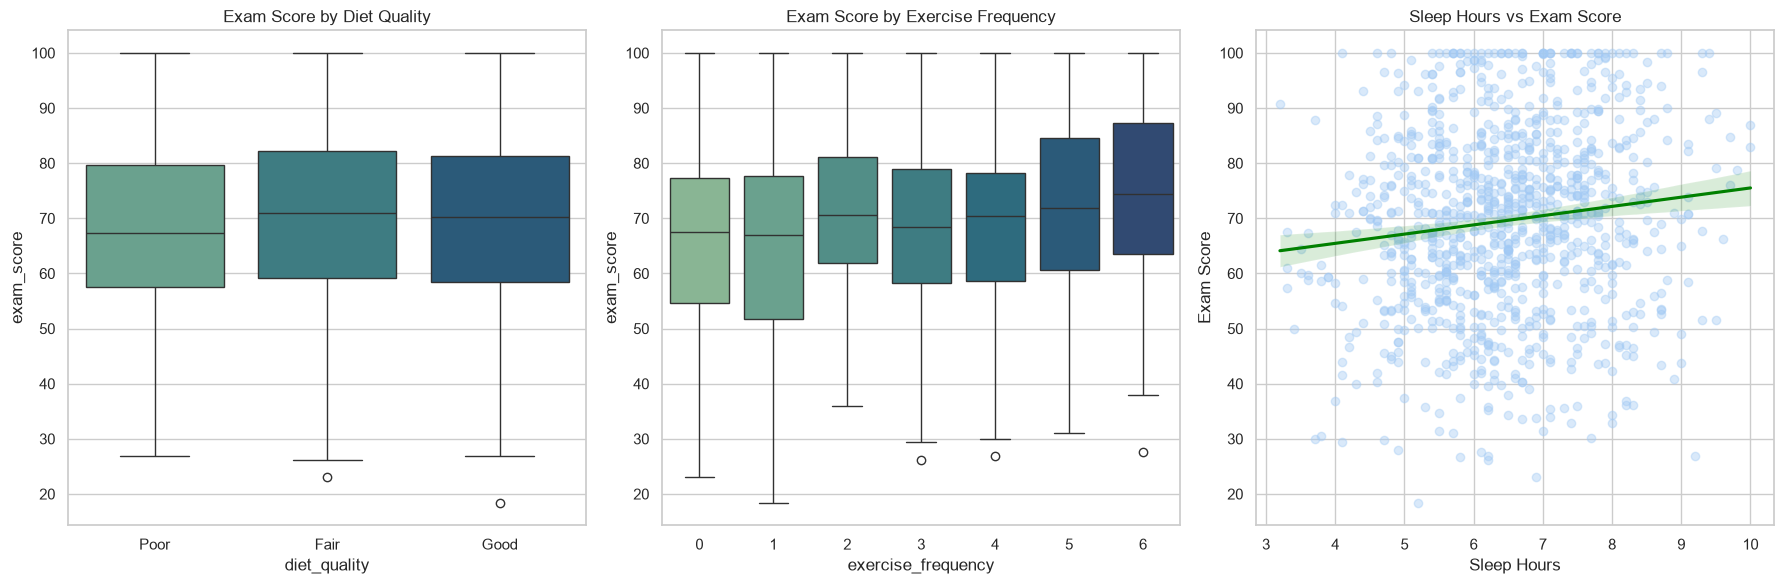

In [65]:
# Check exam score by diet quality, exercise frequency, and sleep hours
fig, axes = plt.subplots(1, 3, figsize=(18,6))

sns.boxplot(data=df_clean, x='diet_quality', y='exam_score', palette='crest',
            order=['Poor','Fair','Good'], ax=axes[0])
axes[0].set_title('Exam Score by Diet Quality')

sns.boxplot(data=df_clean, x='exercise_frequency', y='exam_score', palette='crest', ax=axes[1])
axes[1].set_title('Exam Score by Exercise Frequency')

sns.regplot(data=df_clean, x='sleep_hours', y='exam_score',
            scatter_kws={'alpha':0.4}, line_kws={'color':'green'}, ax=axes[2])
axes[2].set_title('Sleep Hours vs Exam Score')
axes[2].set_xlabel('Sleep Hours')
axes[2].set_ylabel('Exam Score')

plt.tight_layout()
plt.show()

## Talking Point 8: Categorical Background Factors

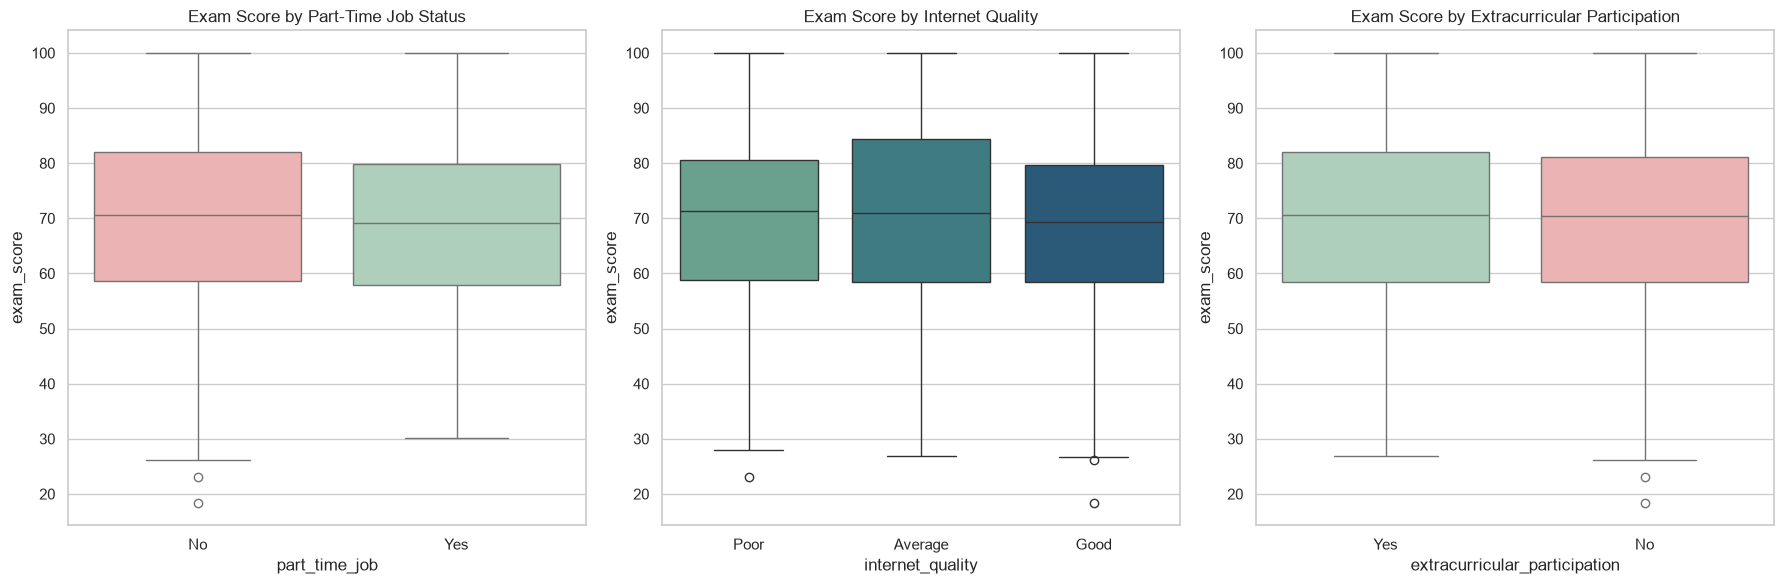

In [66]:
# Check exam score by categorical background factors
yn_colors = {'Yes': '#A8D5BA', 'No': '#F5A9A9'}  # softer pastel green/red
fig, axes = plt.subplots(1, 3, figsize=(18,6))

sns.boxplot(data=df_clean, x='part_time_job', y='exam_score', palette=yn_colors, ax=axes[0])
axes[0].set_title('Exam Score by Part-Time Job Status')

sns.boxplot(data=df_clean, x='internet_quality', y='exam_score', palette='crest',
            order=['Poor','Average','Good'], ax=axes[1])
axes[1].set_title('Exam Score by Internet Quality')

sns.boxplot(data=df_clean, x='extracurricular_participation', y='exam_score', palette=yn_colors, ax=axes[2])
axes[2].set_title('Exam Score by Extracurricular Participation')

plt.tight_layout()
plt.show()

## Talking Point 9 : Synthesis

In [67]:
# Check ranked correlation of every numeric and encoded variable with exam_score
print(corr_matrix_extended['exam_score'].sort_values(ascending=False))

exam_score                  1.000000
study_hours_per_day         0.825419
mental_health_rating        0.321523
exercise_frequency          0.160107
sleep_hours                 0.121683
attendance_percentage       0.089836
diet_quality_encoded        0.015018
extracurricular_encoded     0.000881
age                        -0.008907
part_time_job_encoded      -0.026608
internet_quality_encoded   -0.036298
social_media_hours         -0.166733
netflix_hours              -0.171779
Name: exam_score, dtype: float64


Study hours per day stands out as the dominant predictor (r = 0.83, strong), far ahead of every other variable measured. Mental health rating shows a weak-to-moderate positive relationship (r = 0.32). 
Exercise frequency, sleep hours, and attendance percentage all show only weak or negligible correlation (r < 0.2). Social media hours and Netflix hours both show a mild negative relationship (r ≈ -0.17), 
smaller than intuition might suggest. Notably, study_hours_per_day and mental_health_rating are themselves uncorrelated with each other (r ≈ 0), indicating these are two distinct, 
independent factors rather than one driving the other. Gender and background categorical factors showed no meaningful group differences in exam score. Overall, 
direct study effort is by far the strongest determinant of exam performance among the factors captured in this dataset.